

## Part 1 – Data Exploration
1. Load the dataset using Pandas.
2. Display the first 5 rows.
3. Check dataset information.
4. Check missing values.
5. Display the number of samples in each class.
6. Visualize the class distribution using a count plot.



Load the dataset using Pandas successfully.....
Display the first 5 rows: 
                                   review_description  rating
0  شركه زباله و سواقين بتبرشم و مفيش حتي رقم للشك...      -1
1  خدمة الدفع عن طريق الكي نت توقفت عندي اصبح فقط...       1
2  تطبيق غبي و جاري حذفه ، عاملين اكواد خصم و لما...      -1
3  فعلا تطبيق ممتاز بس لو فى امكانية يتيح لمستخدم...       1
4  سيء جدا ، اسعار رسوم التوصيل لا تمت للواقع ب ص...      -1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32036 entries, 0 to 32035
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_description  32036 non-null  object
 1   rating              32036 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 500.7+ KB
Check dataset information: 
 None
Check missing values.: 
 review_description    0
rating                0
dtype: int64
Display the number of samples in each class: 
 rating
 1    19189
-1    11340
 0     1

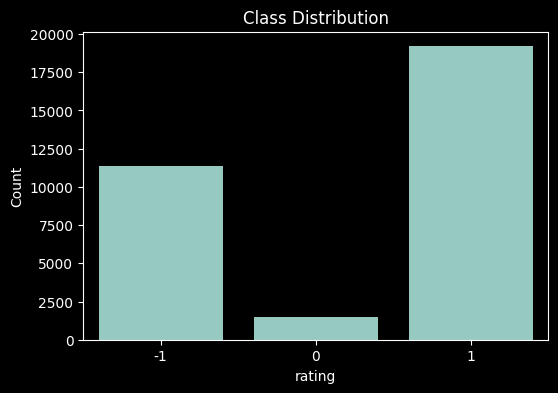

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.datasets import imdb
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GRU,
    LSTM,
    Dense,
    Bidirectional
)
np.random.seed(42)


df = pd.read_excel(r'd:\Material\Machine Learning\NTI\tasks\Arabic Sentiment Analysis.xlsx')
print('Load the dataset using Pandas successfully.....')
print("Display the first 5 rows: \n",df.head())
print('Check dataset information: \n',df.info())
print('Check missing values.: \n',df.isnull().sum())
print('Display the number of samples in each class: \n', df['rating'].value_counts())
plt.style.use('dark_background')
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='rating')
plt.title('Class Distribution')
plt.xlabel('rating')
plt.ylabel('Count')
plt.show()


## Part 2 – Arabic Text Preprocessing
Perform the following preprocessing steps:

• Remove punctuation.

• Remove numbers.

• Remove English letters.

• Remove Arabic diacritics (Tashkeel).

• Normalize Arabic characters (e.g., أ، إ، آ → ا).

• Remove Arabic stopwords.

• Tokenize the text.

Create a new column called clean_text.


In [20]:
pip install pyarabic

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import re
import nltk
from nltk.corpus import stopwords
from pyarabic.araby import strip_tashkeel, strip_tatweel

nltk.download('stopwords')
arabic_stopwords = set(stopwords.words('arabic'))

def preprocess_arabic_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Strip URLs, Mentions, Emojis, and non-Arabic chars, punctuation
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^\u0621-\u064A\s]', ' ', text)

    # 2. Remove Tashkeel & Tatweel
    text = strip_tashkeel(text)
    text = strip_tatweel(text)

    # 3. Normalization
    text = re.sub(r'[أإآ]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'[ؤئ]', 'ء', text)

    # 4. Remove Character Flooding)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # 5. Tokenization
    tokens = text.split()

    # 6. Remove Stopwords
    cleaned_tokens = [word for word in tokens if word not in arabic_stopwords]

    return ' '.join(cleaned_tokens)

df['clean_text'] = df['review_description'].apply(preprocess_arabic_text)
print(df[['review_description', 'clean_text']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                  review_description  \
0  شركه زباله و سواقين بتبرشم و مفيش حتي رقم للشك...   
1  خدمة الدفع عن طريق الكي نت توقفت عندي اصبح فقط...   
2  تطبيق غبي و جاري حذفه ، عاملين اكواد خصم و لما...   
3  فعلا تطبيق ممتاز بس لو فى امكانية يتيح لمستخدم...   
4  سيء جدا ، اسعار رسوم التوصيل لا تمت للواقع ب ص...   

                                          clean_text  
0  شركه زباله سواقين بتبرشم مفيش حتي رقم للشكاوي ...  
1  خدمه الدفع طريق الكي نت توقفت عندي اصبح فقط ال...  
2  تطبيق غبي جاري حذفه عاملين اكواد خصم نستخدمها ...  
3  فعلا تطبيق ممتاز فى امكانيه يتيح لمستخدم التطب...  
4          سيء جدا اسعار رسوم التوصيل تمت للواقع صله  


## Part 3 – Text Encoding
1. Convert cleaned text into sequences using Tokenizer.
2. Display the vocabulary size.
3. Convert each sentence into integer sequences.
4. Apply Padding.
5. Display the shape of the final input data.


In [22]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary size:", vocab_size)

sequences = tokenizer.texts_to_sequences(df['clean_text'])

max_length = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')
print("Shape of final input data:", padded_sequences.shape)

Vocabulary size: 34145
Shape of final input data: (32036, 307)


## Part 4 – Data Splitting
Split the dataset into 80% training and 20% testing.


In [23]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

y_mapped = df['rating'] + 1
y_encoded = to_categorical(y_mapped, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_mapped
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (25628, 307)
X_test shape: (6408, 307)
y_train shape: (25628, 3)
y_test shape: (6408, 3)


## Part 5 – Build a GRU Model
Build a model with:

• Embedding Layer

• GRU Layer

• Dense Output Layer

Compile using Adam, Binary Crossentropy, and Accuracy.


In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout


embedding_dim = 128

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length, mask_zero=True),
    GRU(units=64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    GRU(units=32, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Part 6 – Model Training

Train with:

• Batch Size = 32

• Epochs = 5

Plot training/validation accuracy and loss.


Class Weights: {0: np.float64(0.9416813639035861), 1: np.float64(7.086042910860429), 2: np.float64(0.5564993833272535)}
Epoch 1/5
721/721 ━━━━━━━━━━━━━━━━━━━━ 252s 341ms/step - accuracy: 0.6461 - loss: 0.8692 - val_accuracy: 0.7628 - val_loss: 0.6214
Epoch 2/5
721/721 ━━━━━━━━━━━━━━━━━━━━ 248s 343ms/step - accuracy: 0.8128 - loss: 0.5830 - val_accuracy: 0.7366 - val_loss: 0.6623
Epoch 3/5
721/721 ━━━━━━━━━━━━━━━━━━━━ 250s 346ms/step - accuracy: 0.8873 - loss: 0.3961 - val_accuracy: 0.7304 - val_loss: 0.7405
Epoch 4/5
721/721 ━━━━━━━━━━━━━━━━━━━━ 249s 345ms/step - accuracy: 0.9136 - loss: 0.2921 - val_accuracy: 0.7183 - val_loss: 0.8408
Epoch 5/5
721/721 ━━━━━━━━━━━━━━━━━━━━ 248s 344ms/step - accuracy: 0.9283 - loss: 0.2403 - val_accuracy: 0.7316 - val_loss: 0.8809


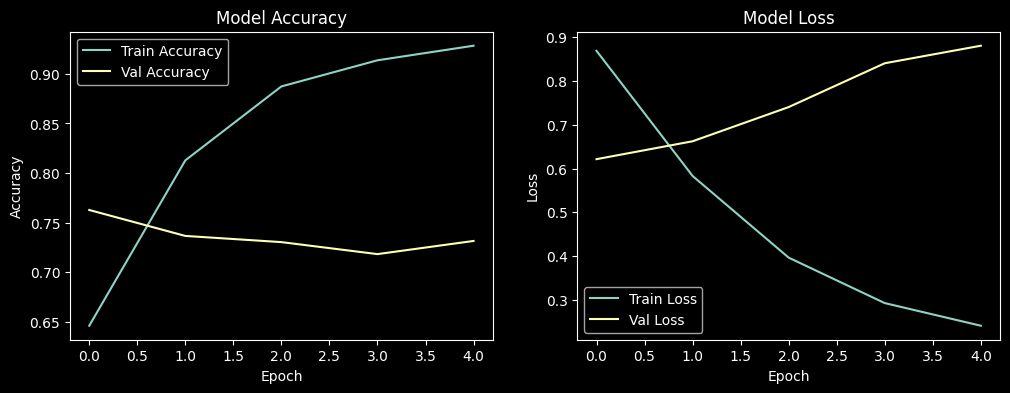

In [26]:
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import time

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_mapped),
    y=y_mapped
)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weight_dict)

start_time = time.time()
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    verbose=1
)
train_time = time.time() - start_time

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Part 7 – Model Evaluation
Evaluate using:

• Test Accuracy

• Confusion Matrix

• Classification Report

Answer:
1. What is the final test accuracy?
2. Which class was predicted better?
3. Did the model show signs of overfitting? Explain


201/201 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step
Final Test Accuracy: 72.64% 

    Classification Report 
               precision    recall  f1-score   support

Negative (-1)       0.78      0.72      0.75      2268
  Neutral (0)       0.09      0.32      0.15       302
 Positive (1)       0.88      0.76      0.82      3838

     accuracy                           0.73      6408
    macro avg       0.59      0.60      0.57      6408
 weighted avg       0.81      0.73      0.76      6408



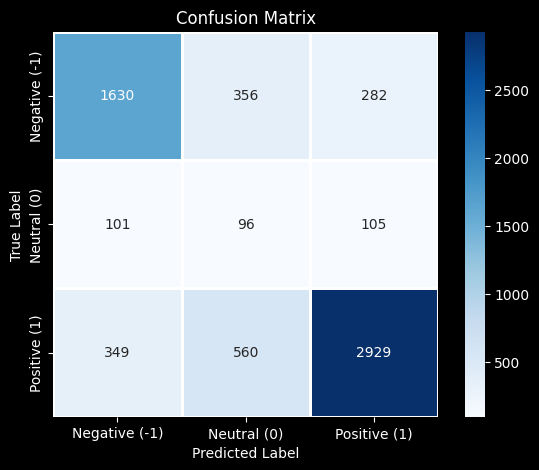

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}% \n")

target_names = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']
print("    Classification Report ")
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
    linewidths=1, xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Bonus Challenge
Repeat the experiment using SimpleRNN instead of GRU.

Compare:

• Test Accuracy

• Number of Parameters

Conclude which model performed better and why.


In [28]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from sklearn.metrics import accuracy_score

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length, mask_zero=True),
    SimpleRNN(units=64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    SimpleRNN(units=32, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_rnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time_rnn = time.time()
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
rnn_train_time = time.time() - start_time_rnn

y_pred_rnn = np.argmax(model_rnn.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
rnn_accuracy = accuracy_score(y_true, y_pred_rnn)


gru_params = model.count_params()
rnn_params = model_rnn.count_params()

gru_accuracy = accuracy_score(y_true, np.argmax(model.predict(X_test), axis=1))



Epoch 1/5


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


721/721 ━━━━━━━━━━━━━━━━━━━━ 117s 157ms/step - accuracy: 0.7509 - loss: 0.6603 - val_accuracy: 0.8100 - val_loss: 0.5047
Epoch 2/5
721/721 ━━━━━━━━━━━━━━━━━━━━ 108s 150ms/step - accuracy: 0.8494 - loss: 0.4558 - val_accuracy: 0.8385 - val_loss: 0.4768
Epoch 3/5
721/721 ━━━━━━━━━━━━━━━━━━━━ 115s 160ms/step - accuracy: 0.8842 - loss: 0.3478 - val_accuracy: 0.8346 - val_loss: 0.5096
Epoch 4/5
721/721 ━━━━━━━━━━━━━━━━━━━━ 116s 161ms/step - accuracy: 0.9036 - loss: 0.2864 - val_accuracy: 0.8197 - val_loss: 0.5430
Epoch 5/5
721/721 ━━━━━━━━━━━━━━━━━━━━ 114s 158ms/step - accuracy: 0.9261 - loss: 0.2262 - val_accuracy: 0.8115 - val_loss: 0.6466
201/201 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step
201/201 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step


In [29]:
comparison_df = pd.DataFrame({
    'Metric': ['Total Parameters', 'Test Accuracy (%)'],
    'GRU Model': [f"{gru_params:,}", f"{gru_accuracy * 100:.2f}%"],
    'SimpleRNN Model': [f"{rnn_params:,}", f"{rnn_accuracy * 100:.2f}%"]
})

print("\n=================== Model Comparison ===================")
print(comparison_df.to_string(index=False))


=================== Model Comparison ===================
           Metric GRU Model SimpleRNN Model
 Total Parameters 4,418,371       4,387,171
Test Accuracy (%)    72.64%          80.63%
